# Практична робота 5.3. Практичне використання інструментів візуалізації даних
## Варіант 7. Дашборд оперативного огляду обстановки

**Номер за журналом:** 7

**Завдання варіанта:** інтегрувати 3–5 візуалізацій (карта, часовий ряд, структура сил, таблиця подій) в єдиний дашборд (Power BI / Tableau / Python Dash). **Очікуваний результат:** прототип дашборда з мінімальною взаємодією.

**Що зроблено:**
| Файл | Призначення |
|---|---|
| `5.3task.ipynb` | цей ноутбук: підготовка даних, обґрунтування вибору візуалізацій, побудова кожного елемента, аналітичні висновки |
| `figures.py` | спільний модуль побудови елементів дашборда |
| `app.py` | **інтерактивний дашборд на Python Dash** (фільтри за напрямками, типами подій і періодом) |
| `dashboard.html` | статична версія дашборда: відкривається в браузері без Python, з hover, zoom і вмиканням/вимиканням шарів |
| `data/events.csv`, `data/forces.csv` | синтетичні навчальні дані |
| `img/dashboard.png` | знімок екрана інтерактивного дашборда |

> Усі дані **синтетичні** та згенеровані в цьому ноутбуці. Район, напрямки й координати умовні, реальних даних немає.

In [1]:
import os
import numpy as np
import pandas as pd
import plotly.io as pio
import figures as F

def show(fig, width=1100, height=480):
    # статичний PNG, щоб графіки було видно і на GitHub; інтерактивна версія є в app.py та dashboard.html
    try:
        fig.show(renderer="png", width=width, height=height)
    except Exception:
        fig.show()

## 1. Підготовчий етап
### 1.1. Вихідні дані
Моделюємо дані, які штаб отримує від підрозділів за 30 діб:
- **журнал подій** `events.csv`: час, напрямок, тип події, інтенсивність (1–5), умовні координати X/Y (км);
- **оцінка угруповання противника** `forces.csv`: кількість виявлених підрозділів (рота/батарея) за типами та напрямками.

In [2]:
os.makedirs("data", exist_ok=True)
events_raw, forces = F.generate_data(seed=7)
events_raw.to_csv("data/events.csv", index=False)
forces.to_csv("data/forces.csv", index=False)
print("events:", events_raw.shape, "| forces:", forces.shape)
events_raw.head()

events: (837, 8) | forces: (24, 3)


,event_id,datetime,date,direction,event_type,intensity,x_km,y_km
0,E00011,2026-08-24 00:10:00,2026-08-24,Напрямок В,Авіаудар (КАБ),2.0,40.07,13.22
1,E00019,2026-08-24 01:23:00,2026-08-24,Напрямок В,Дії ДРГ,1.0,38.66,19.18
2,E00001,2026-08-24 02:51:00,2026-08-24,Напрямок А,Дії ДРГ,1.0,9.57,30.86
3,E00014,2026-08-24 03:29:00,2026-08-24,Напрямок В,Удар БпЛА,2.0,37.61,17.53
4,E00007,2026-08-24 04:28:00,2026-08-24,Напрямок Б,Артобстріл,2.0,18.08,24.18


### 1.2. Перевірка повноти, пропусків і дублікатів

In [3]:
print("Пропуски:\n", events_raw.isna().sum()[lambda s: s > 0])
print("Дублікатів за event_id:", events_raw.duplicated("event_id").sum())
print("Координати в межах району:", events_raw["x_km"].between(0, 60).all() and events_raw["y_km"].between(0, 40).all())
print("Період:", events_raw["date"].min(), "—", events_raw["date"].max())

Пропуски:
 intensity    4
dtype: int64
Дублікатів за event_id: 3
Координати в межах району: True
Період: 2026-08-24 — 2026-09-22


In [4]:
events = F.clean_events(events_raw)          # видалення дублікатів, пропуски інтенсивності → медіана за типом події
print("Після очищення:", events.shape, "| пропусків:", events.isna().sum().sum())
events.groupby("direction").agg(подій=("event_id", "count"), сер_інтенсивність=("intensity", "mean")).round(2)

Після очищення: (834, 8) | пропусків: 0


,подій,сер_інтенсивність
direction,,
Напрямок А,171,1.98
Напрямок Б,343,2.81
Напрямок В,200,2.19
Напрямок Г,120,2.08


### 1.3. Вибір типів візуалізації
Дашборд адресований **оперативному рівню**. Він має за 10–15 секунд відповісти на питання: *що відбувається, де, як змінюється і що далі*. Тип кожного графіка вибирається за характером даних і аналітичною задачею:

| Питання штабу | Дані | Задача аналізу | Візуалізація |
|---|---|---|---|
| Скільки і як змінюється? | агрегати | загальна оцінка | **KPI-картки** (кількість, зміна до попереднього тижня, найактивніший напрямок) |
| Де відбуваються події? | координати + категорія | просторовий розподіл | **карта подій** (колір — тип, розмір — інтенсивність) |
| Як змінюється активність? | подія × доба × напрямок | динаміка, піки | **часовий ряд** за напрямками з ковзним середнім |
| Які сили протистоять? | ієрархія напрямок → тип | структура / частки | **treemap** (площа пропорційна кількості підрозділів) |
| Який характер дій? | напрямок × тип | порівняння структури | **стовпчикова діаграма з накопиченням** |
| Що сталося останнім? | окремі записи | деталізація | **таблиця подій** з виділенням високої інтенсивності |

**Принципи оформлення (вимоги 4.2 методики):**
- **палітра військового стилю:** напрямки позначено холодними тонами (NATO blue `#1F4E79`, олива `#556B2F`, світлий NATO blue, сіро-оливковий); типи подій теплими земляними тонами (сієна, пісок, коричневий, темна олива). **Штурмові дії** виділено темно-червоним, бо в системі умовних позначень NATO червоний означає противника. Заголовки, шапка таблиці та KPI-картки в оливкових тонах;
- **сталі кольори:** той самий напрямок або тип події має той самий колір на всіх графіках;
- **мінімум зайвого:** без 3D, тіней і декоративних фонів; тонка сітка;
- **читабельні підписи** українською, **зрозумілий масштаб** (км на карті, «подій за добу» на часовому ряду);
- **короткі пояснення** в заголовках і підзаголовках графіків.

## 2. Технічний етап: побудова елементів
### 2.1. KPI-картки

In [5]:
pd.Series(F.kpis(events), name="значення").to_frame()

,значення
Подій за період,834
Подій за 7 діб,223
Зміна до попередніх 7 діб,+12 %
Найактивніший напрямок (7 діб),Напрямок Б
Середня інтенсивність,2.4 / 5


### 2.2. Карта подій

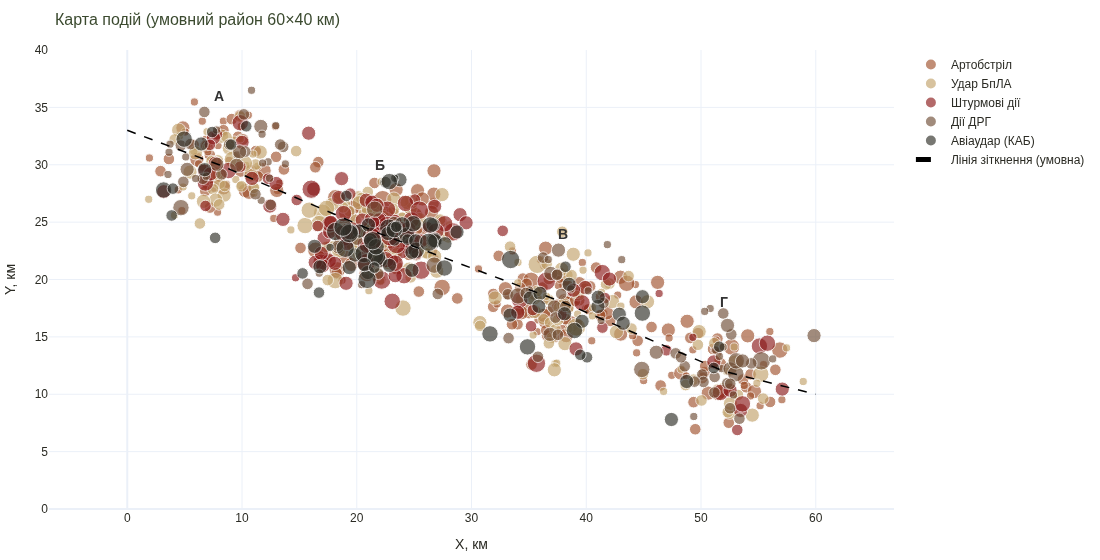

In [6]:
show(F.fig_map(events), height=560)

### 2.3. Часовий ряд за напрямками

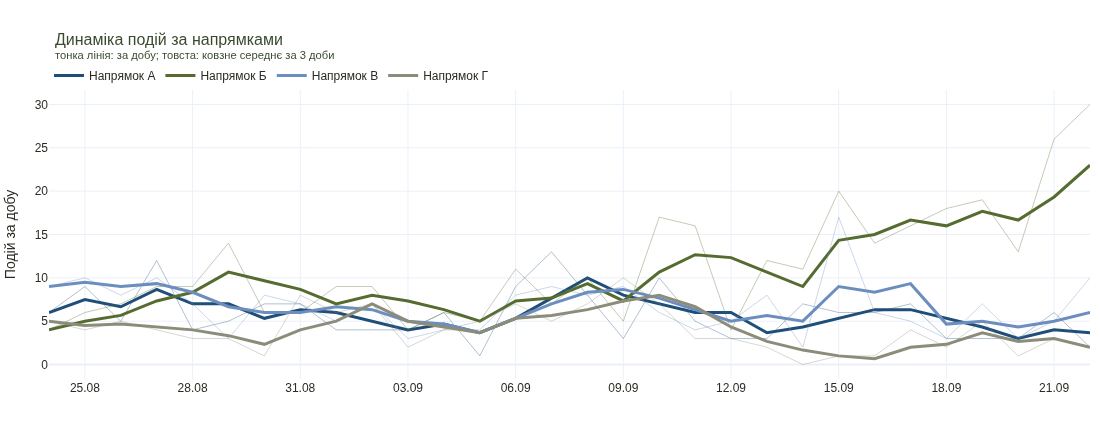

In [7]:
show(F.fig_timeseries(events), height=430)

### 2.4. Структура сил противника

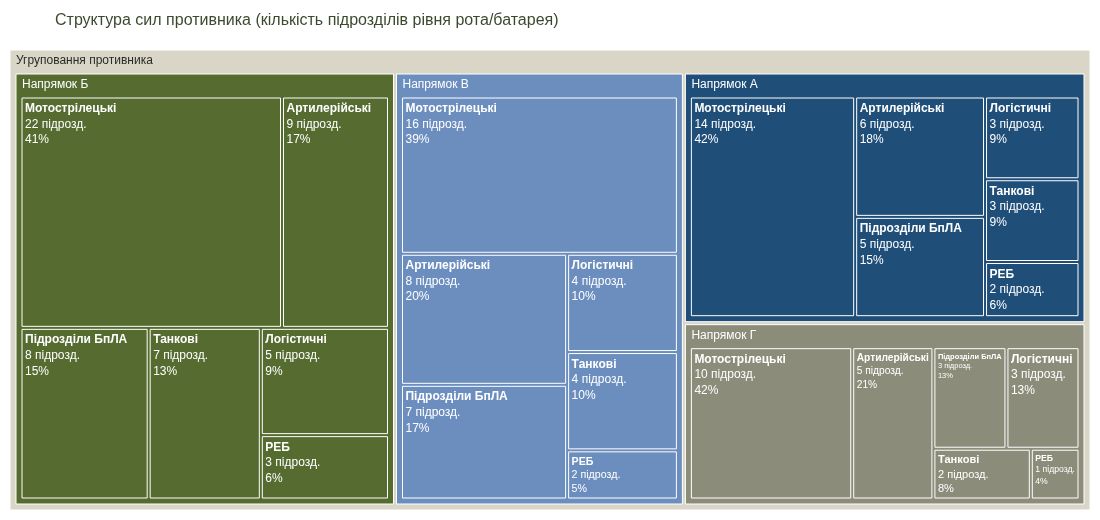

In [8]:
show(F.fig_forces(forces), height=520)

### 2.5. Характер подій за напрямками

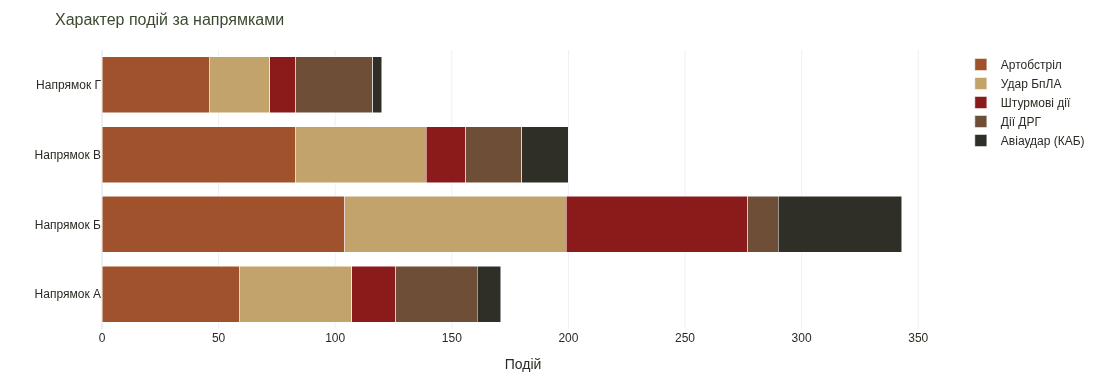

In [9]:
show(F.fig_types(events), height=380)

### 2.6. Таблиця останніх подій

In [10]:
F.table_latest(events)

,Час,Напрямок,Тип події,Інтенсивність,"X, км","Y, км"
833,22.09 23:38,Напрямок Б,Удар БпЛА,3,24.40,26.71
832,22.09 22:39,Напрямок Б,Штурмові дії,4,20.94,22.98
831,22.09 22:08,Напрямок Б,Авіаудар (КАБ),5,18.80,24.56
830,22.09 21:14,Напрямок В,Удар БпЛА,2,37.53,16.46
829,22.09 21:02,Напрямок Б,Штурмові дії,2,21.50,25.01
828,22.09 20:51,Напрямок Б,Удар БпЛА,4,22.71,21.57
827,22.09 20:32,Напрямок В,Штурмові дії,3,34.03,17.14
826,22.09 20:12,Напрямок В,Артобстріл,2,31.90,18.74
825,22.09 20:00,Напрямок Б,Удар БпЛА,2,20.25,23.96
824,22.09 18:50,Напрямок Б,Удар БпЛА,3,27.44,27.40


## 3. Інтеграція в дашборд
### 3.1. Інтерактивний дашборд (Python Dash)
`app.py` поєднує всі елементи на одній сторінці та додає **мінімальну взаємодію**:
- фільтр **напрямків**: оновлює KPI, карту, часовий ряд, структуру сил, діаграму типів і таблицю;
- фільтр **типів подій**;
- вибір **періоду** (DatePickerRange);
- у таблиці сортування за будь-яким стовпцем; на графіках hover, zoom і вмикання/вимикання легенди.

Запуск:
```bash
pip install dash plotly pandas numpy
python app.py        # відкрити http://127.0.0.1:8050
```

### 3.2. Статична версія `dashboard.html`
Для перегляду без Python генеруємо одну HTML-сторінку з усіма елементами. Бібліотека Plotly підключається з CDN, тому для відкриття потрібен інтернет.

In [11]:
from plotly.offline import get_plotlyjs_version
k = F.kpis(events)
cards = "".join(f'<div class="card"><div class="k">{a}</div><div class="v">{b}</div></div>' for a, b in k.items())
div = lambda fig, h: pio.to_html(fig.update_layout(height=h), include_plotlyjs=False, full_html=False)
html = f"""<!DOCTYPE html><html lang="uk"><head><meta charset="utf-8"><title>Оперативний огляд обстановки</title>
<meta name="viewport" content="width=device-width, initial-scale=1">
<script src="https://cdn.plot.ly/plotly-{get_plotlyjs_version()}.min.js"></script>
<style>body{{font-family:Segoe UI,Arial,sans-serif;margin:0 auto;padding:12px 18px;max-width:1500px;color:#2B2B24}} h2{{color:#3B4A2F}}
.sub{{color:#6c757d}} .cards{{display:flex;gap:12px;flex-wrap:wrap;margin:12px 0}}
.card{{background:#EEF0E6;border-left:4px solid #556B2F;border-radius:8px;padding:10px 14px;flex:1;min-width:150px}}
.k{{font-size:12px;color:#6c757d}} .v{{font-size:22px;font-weight:600}}
.grid{{display:grid;grid-template-columns:1.1fr 1fr;gap:10px}} @media(max-width:900px){{.grid{{grid-template-columns:1fr}}}}</style></head>
<body><h2 style="margin:0">Дашборд оперативного огляду обстановки</h2>
<div class="sub">Навчальний прототип · синтетичні дані · умовний район 60×40 км · період {events['date'].min():%d.%m}–{events['date'].max():%d.%m.%Y}</div>
<div class="cards">{cards}</div>
<div class="grid"><div>{div(F.fig_map(events), 440)}</div><div>{div(F.fig_timeseries(events), 440)}</div>
<div>{div(F.fig_forces(forces), 420)}</div><div>{div(F.fig_types(events), 420)}</div></div>
{div(F.fig_table(events), 470)}
</body></html>"""
open("dashboard.html", "w", encoding="utf-8").write(html)
print("dashboard.html:", round(os.path.getsize("dashboard.html") / 1024), "KB")

dashboard.html: 139 KB


### 3.3. Знімок екрана інтерактивного дашборда (Dash)
![Дашборд](img/dashboard.png)

## 4. Аналітичний етап
### 4.1. Кількісна перевірка патернів, помічених на графіках

In [12]:
last = events["date"].max()
w_last = events[events["date"] > last - pd.Timedelta(days=7)]
w_prev = events[(events["date"] <= last - pd.Timedelta(days=7)) & (events["date"] > last - pd.Timedelta(days=14))]
cmp = pd.DataFrame({"попередні 7 діб": w_prev.groupby("direction").size(),
                    "останні 7 діб": w_last.groupby("direction").size()})
cmp["зміна, %"] = ((cmp["останні 7 діб"] / cmp["попередні 7 діб"] - 1) * 100).round(0)
cmp["сер. інтенсивність (7 діб)"] = w_last.groupby("direction")["intensity"].mean().round(2)
cmp["частка штурмів і КАБ (7 діб), %"] = (w_last.assign(h=w_last["event_type"].isin(["Штурмові дії", "Авіаудар (КАБ)"]))
                                           .groupby("direction")["h"].mean() * 100).round(0)
cmp

,попередні 7 діб,останні 7 діб,"зміна, %",сер. інтенсивність (7 діб),"частка штурмів і КАБ (7 діб), %"
direction,,,,,
Напрямок А,37,30,-19.0,2.03,3.0
Напрямок Б,85,136,60.0,3.32,38.0
Напрямок В,51,39,-24.0,2.38,21.0
Напрямок Г,26,18,-31.0,2.00,0.0


In [13]:
peak = events.groupby(["date", "direction"]).size().sort_values(ascending=False).head(3)
print("Три найактивніші доби:"); print(peak.to_string())
f = forces.groupby("direction")["units"].sum()
print("\nЧастка напрямків у загальній кількості підрозділів противника, %:"); print((f / f.sum() * 100).round(0).to_string())

Три найактивніші доби:
date        direction 
2026-09-22  Напрямок Б    30
2026-09-21  Напрямок Б    26
2026-09-15  Напрямок Б    20

Частка напрямків у загальній кількості підрозділів противника, %:
direction
Напрямок А    22.0
Напрямок Б    36.0
Напрямок В    27.0
Напрямок Г    16.0


### 4.2. Аналітичні висновки

1. **Напрямок Б — головне зусилля противника.** На ньому зафіксовано 41 % усіх подій за період (343 із 834). За останні 7 діб активність зросла на **60 %** порівняно з попереднім тижнем (136 проти 85 подій). Три найактивніші доби періоду теж припадають на Б, зокрема пік 22.09 (30 подій). Часовий ряд показує стійке наростання з 15.09, а не разовий сплеск.
2. **Змінюється характер дій, а не лише їх кількість.** На напрямку Б середня інтенсивність за тиждень становить 3.3 із 5 (на інших напрямках 2.0–2.4). Частка штурмових дій і авіаударів КАБ сягає 38 %. Таке поєднання типове для підготовки або ведення наступальних дій.
3. **Склад сил це підтверджує.** На напрямку Б зосереджено 36 % виявлених підрозділів противника, найбільше в усіх категоріях, зокрема 7 танкових і 8 підрозділів БпЛА.
4. **Напрямок Г затихає** (−31 % за тиждень, штурмових дій немає). Разом зі зниженням на А (−19 %) і В (−24 %) це може свідчити про перекидання засобів на напрямок Б. Висновок потребує підтвердження розвідданими про переміщення.
5. **Для штабу:** пріоритезувати напрямок Б у плануванні вогневого ураження та протиповітряного прикриття, посилити розвідку на стиках Б/А і Б/В. Для напрямку Г оцінити можливість вивільнення резервів. Моніторинг вести за KPI «зміна до попередніх 7 діб» і часткою штурмових дій.

### 4.3. Оцінка дашборда
- **Одна сторінка відповідає на ключові питання:** що відбувається (KPI), де (карта), як змінюється (часовий ряд), які сили (treemap), який характер дій (стовпчики), що саме сталося (журнал).
- **Взаємодія:** фільтри напрямків, типів і періоду в `app.py` оновлюють усі елементи одночасно. У статичній версії доступні hover, zoom і вибір шарів у легенді.
- **Обмеження прототипу:** дані синтетичні; координати умовні, без картографічної підкладки; оцінка сил статична (без динаміки). Для практичного використання потрібні підключення до реального джерела даних з оновленням, розмежування доступу та картографічна основа в системі координат штабу.

## 5. Контрольні запитання для самоперевірки

| № | Запитання | Відповідь |
|---|---|---|
| 1 | Чи відповідає тип обраної візуалізації сутності даних? | **Так.** Координати подій показано на карті, динаміку часовим рядом, ієрархічну структуру сил treemap-діаграмою, порівняння характеру дій стовпчиковою діаграмою з накопиченням, окремі записи таблицею. Обґрунтування наведено в таблиці розділу 1.3. |
| 2 | Чи немає перевантаження графіка зайвими елементами? | **Так, немає.** На кожному графіку одна аналітична думка. Декору немає, підписи короткі. На часовому ряду сирі добові значення показано напівпрозорими тонкими лініями, щоб вони не заважали читати тренд. Фільтри в `app.py` дозволяють прибрати зайві напрямки чи типи подій. |
| 3 | Чи можна за 5 секунд зрозуміти, що показує графік? | **Так.** KPI-картки вгорі одразу дають відповідь («Подій за 7 діб: 223», «+12 %», «Найактивніший напрямок: Б»). Товста лінія напрямку Б на часовому ряду явно йде вгору, а найбільший прямокутник treemap відповідає напрямку Б. |
| 4 | Чи наявні ключові висновки за даними? | **Так.** У розділі 4.2 сформульовано 5 висновків, кожен підкріплений цифрами з розділу 4.1: +60 % подій на Б, 38 % штурмів і КАБ, 36 % підрозділів противника, спад на Г −31 %. |
| 5 | Чи сформульовано приклад впливу інформації на штабні рішення? | **Так.** Висновок 5: пріоритезувати напрямок Б у плануванні вогневого ураження та ППО, посилити розвідку на стиках Б/А і Б/В, оцінити можливість вивільнення резервів з напрямку Г. |